# Modules

In [1]:
import sys
sys.path.insert(1, "../module")
import numpy as np      
import snflics
from skimage.transform import resize
from netCDF4 import Dataset                             
from scipy.ndimage import zoom
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt                         
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")
import cartopy.io.shapereader as shpreader

--------------------------------------------------------------------------
detected:

  Local host:            host839
  Device name:           mlx5_bond_0
  Device vendor ID:      0x02c9
  Device vendor part ID: 4127

Default device parameters will be used, which may result in lower
performance.  You can edit any of the files specified by the
btl_openib_device_param_files MCA parameter to set values for your
device.

NOTE: You can turn off this warning by setting the MCA parameter
      btl_openib_warn_no_device_params_found to 0.
--------------------------------------------------------------------------
--------------------------------------------------------------------------
No OpenFabrics connection schemes reported that they were able to be
used on a specific port.  As such, the openib BTL (OpenFabrics
support) will be disabled for this port.

  Local host:           host839
  Local device:         mlx5_bond_0
  Local port:           1
  CPCs attempted:       rdmacm, udcm
-------

In [2]:
geodata = Dataset("/gws/ssde/j25b/swift/rt_cores/geoloc_grids/nxny2268_2080_nxnyds164580_blobdx0.04491576_arean41_n27_27_79.nc")
lons = geodata["lons_mid"][:]
lats = geodata["lats_mid"][:]

In [3]:
# replace missing values
filtered_lons = np.where(lons == -999.999, np.nan, lons)
filtered_lats = np.where(lats == -999.999, np.nan, lats)

In [4]:
lons.shape

(2079, 2263)

# Core data 

In [5]:
year = "2025"
month = "07"
day = "15"
hour = "12"
minute = "00"

In [6]:
path_core = f"/gws/ssde/j25b/swift/rt_cores/{year}/{month}/{day}/{hour}{minute}"
file = f"{path_core}/Convective_struct_extended_{year}{month}{day}{hour}{minute}_000.nc"

In [7]:
data = Dataset(file, mode='r')

# wavelet power maxima's coordinates
x0_lat = data["Pmax_lat"][:]
x0_lon = data["Pmax_lon"][:]

# wavelet power arrays
cores  = data["cores"][:, :]

In [8]:
# cloud top temperature and wavelet power arrays
binary_cores = (cores != 0).astype(int)

In [9]:
# Earth radius in km
R = 6371.0

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.deg2rad, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# choose a representative point near the centre
i = lats.shape[0] // 2
j = lats.shape[1] // 2

# meridional spacing (north–south)
dy = haversine(
    lats[i, j], lons[i, j],
    lats[i+1, j], lons[i+1, j]
)

# zonal spacing (east–west)
dx = haversine(
    lats[i, j], lons[i, j],
    lats[i, j+1], lons[i, j+1]
)

print(f"dy (N–S spacing): {dy:.2f} km")
print(f"dx (E–W spacing): {dx:.2f} km")


dy (N–S spacing): 3.05 km
dx (E–W spacing): 3.09 km


# Plot Dakar Context Domain with Core Data

In [10]:
cores.shape

(2079, 2263)

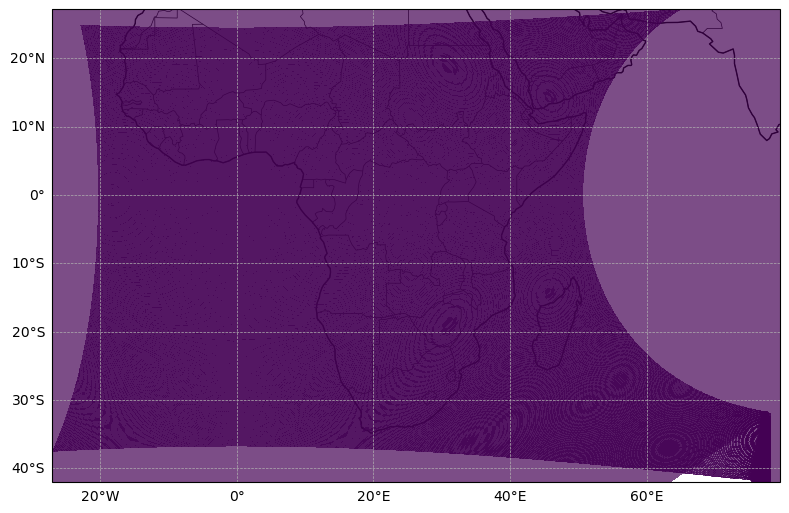

In [11]:
# Create figure and axis
fig = plt.figure(figsize=(8, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

extent = (
    np.nanmin(filtered_lons),
    np.nanmax(filtered_lons),
    np.nanmin(filtered_lats),
    np.nanmax(filtered_lats),    
)

ax.set_extent(extent, crs=ccrs.PlateCarree())


# Base features
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5, zorder=1)

# Load Natural Earth country boundaries
shapename = 'admin_0_countries'
countries_shp = shpreader.natural_earth(resolution='10m', category='cultural', name=shapename)

# Gridlines
gl = ax.gridlines(draw_labels=True, alpha=1, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

contour_core = ax.pcolormesh(
    lons, lats, np.ones(lats.shape),
    transform=ccrs.PlateCarree(),
    alpha=0.7,
    zorder=2
)
plt.tight_layout()
plt.show()

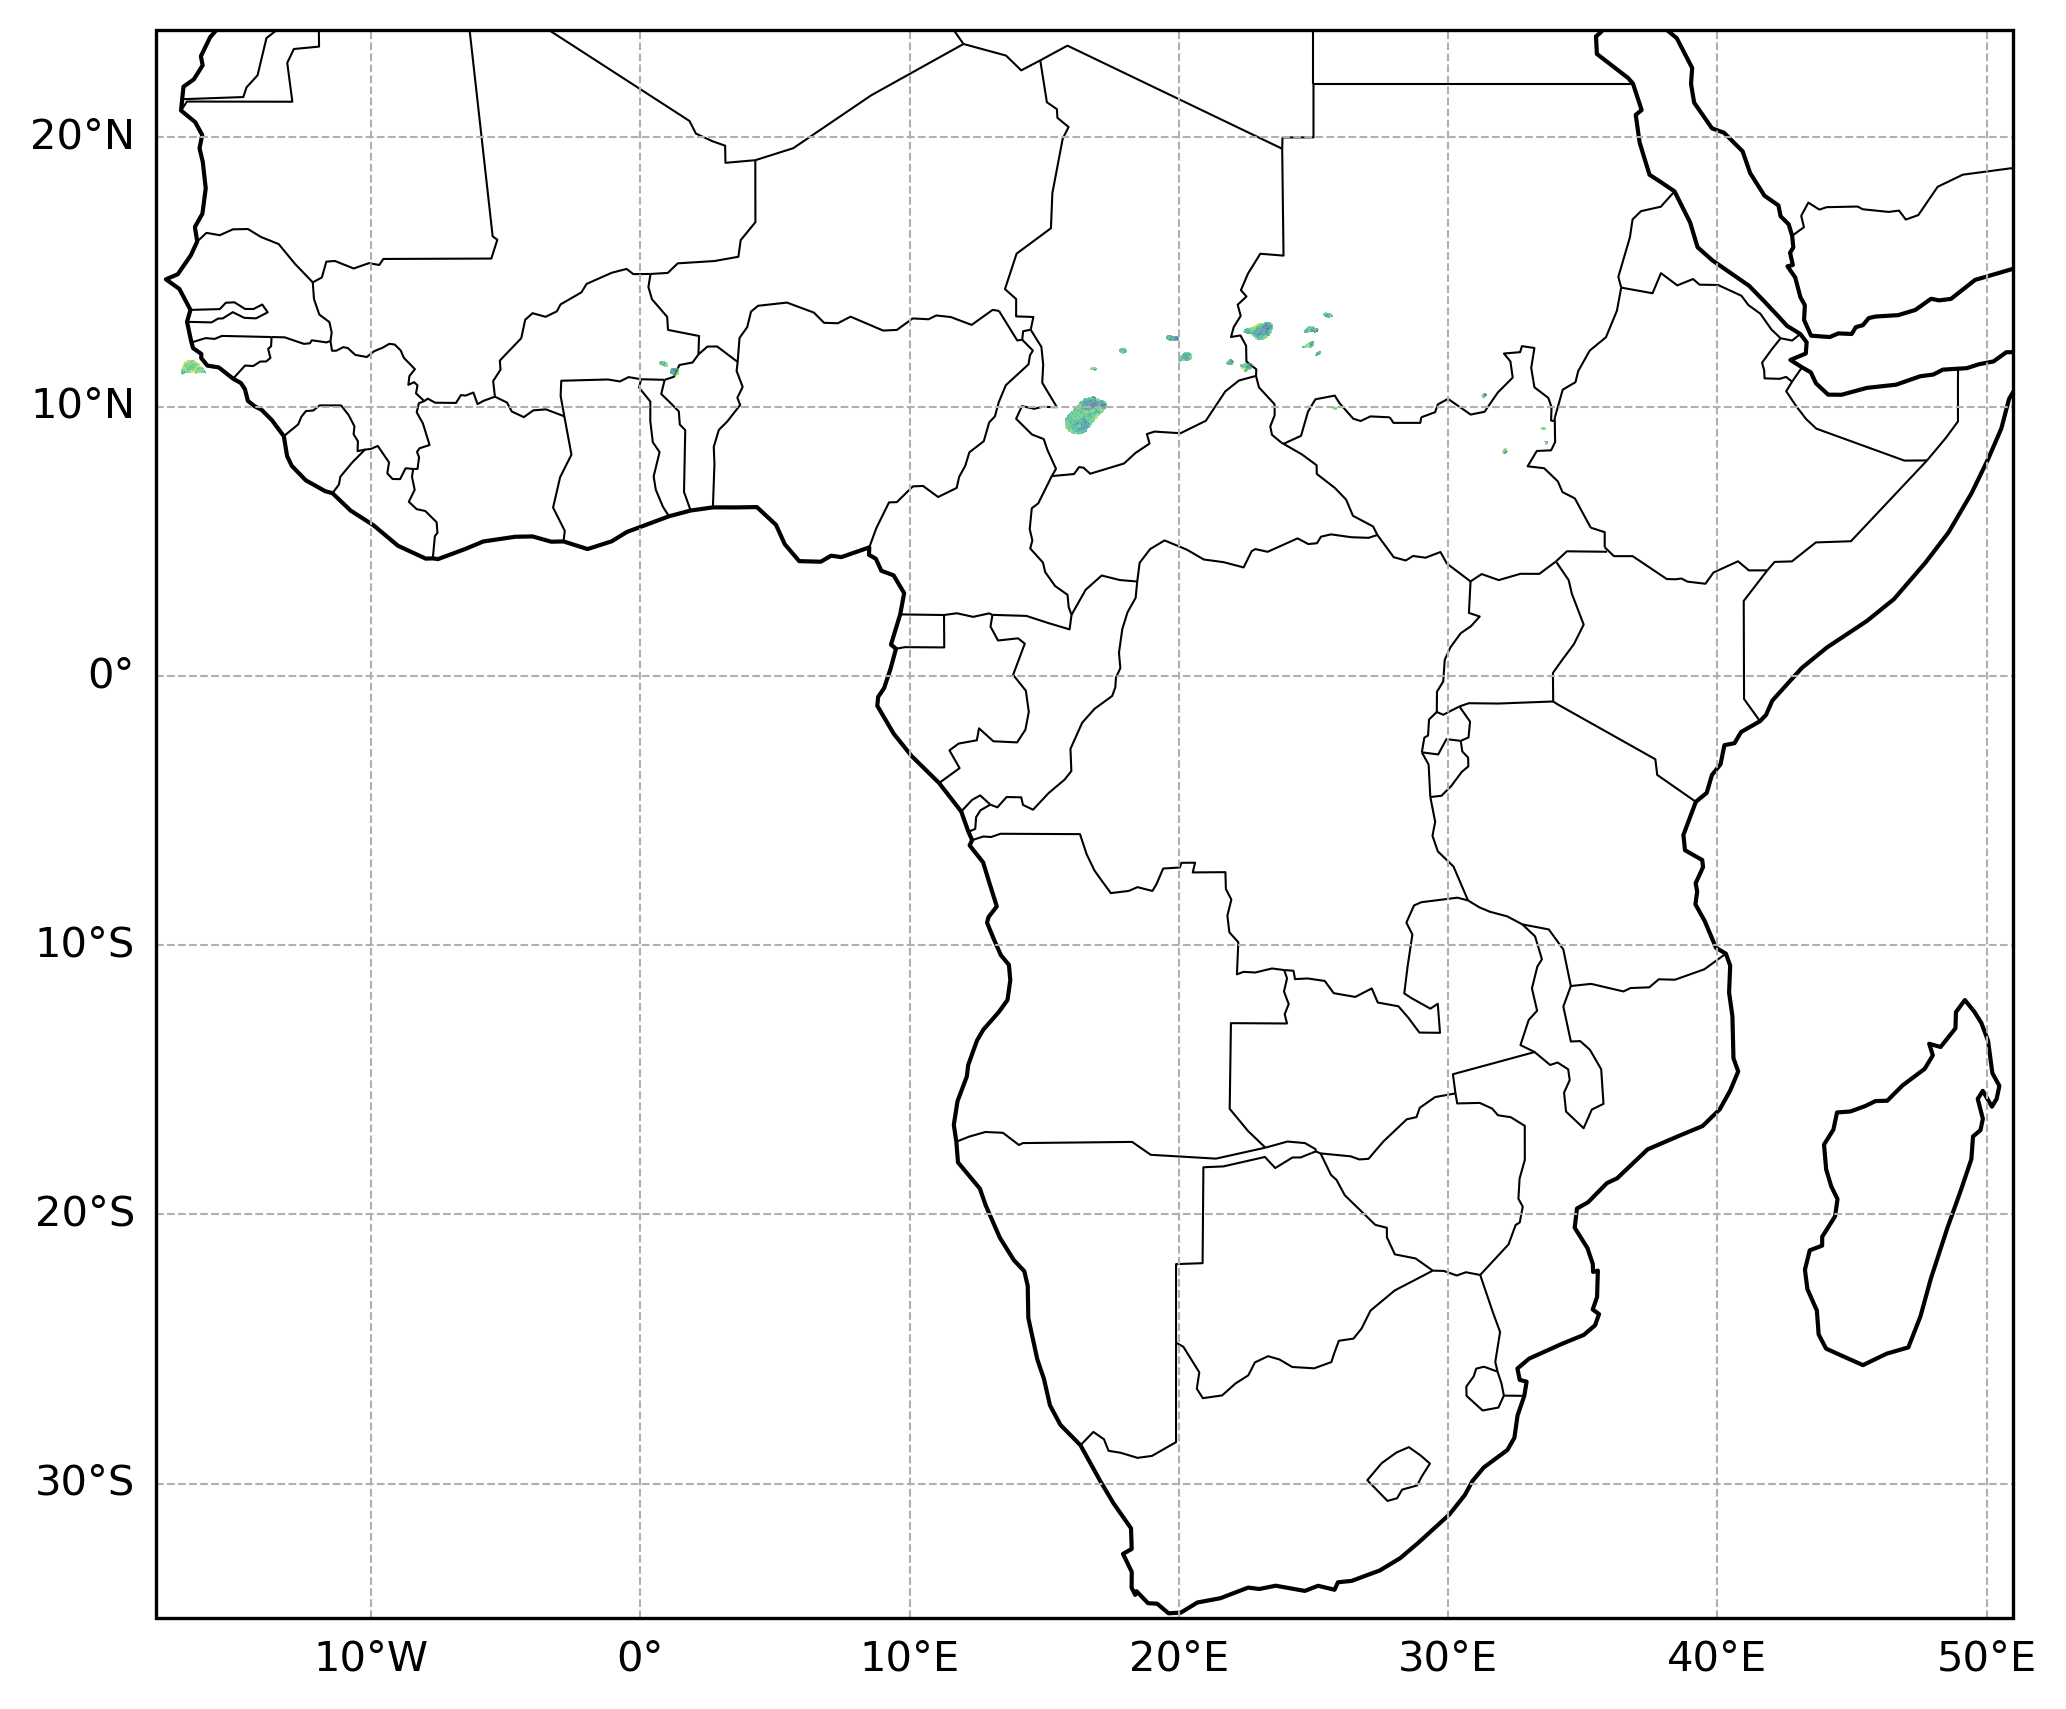

In [12]:
fig = plt.figure(figsize=(7, 10), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

extent = (-18, 51, -35, 24)

ax.set_extent(extent, crs=ccrs.PlateCarree())

# Base features
ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5, zorder=1)

# Load Natural Earth country boundaries
shapename = 'admin_0_countries'
countries_shp = shpreader.natural_earth(resolution='10m', category='cultural', name=shapename)

# Gridlines
gl = ax.gridlines(draw_labels=True, alpha=1, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

contour_core = ax.pcolormesh(
    lons, lats, cores,
    transform=ccrs.PlateCarree(),
    alpha=0.7,
    zorder=2
)
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from netCDF4 import Dataset

LAT_MIN = -35
LAT_MAX = 24
LON_MIN = -18
LON_MAX = 51

out_dir = "/home/users/mendrika/Object-Based-LSTMConv/notebooks/model/deploy/geolocation"

# load NRT geolocation
geodata = Dataset(
    "/gws/ssde/j25b/swift/rt_cores/geoloc_grids/"
    "nxny2268_2080_nxnyds164580_blobdx0.04491576_arean41_n27_27_79.nc"
)

lats = geodata["lats_mid"][:]
lons = geodata["lons_mid"][:]

# TEMPORARILY convert missing to NaN for masking
lats_nan = np.where(lats == -999.999, np.nan, lats)
lons_nan = np.where(lons == -999.999, np.nan, lons)

# Africa mask
mask = (
    (lats_nan >= LAT_MIN) &
    (lats_nan <= LAT_MAX) &
    (lons_nan >= LON_MIN) &
    (lons_nan <= LON_MAX)
)

rows = np.where(mask.any(axis=1))[0]
cols = np.where(mask.any(axis=0))[0]

row_min, row_max = rows[0], rows[-1]
col_min, col_max = cols[0], cols[-1]

# crop NRT grid
lats_crop = lats_nan[row_min:row_max+1, col_min:col_max+1]
lons_crop = lons_nan[row_min:row_max+1, col_min:col_max+1]

# convert BACK to portal-required missing value
lats_crop = np.where(np.isnan(lats_crop), -999.999, lats_crop)
lons_crop = np.where(np.isnan(lons_crop), -999.999, lons_crop)

# save NRT Africa geolocation
np.save(f"{out_dir}/nrt_lats_africa.npy", lats_crop)
np.save(f"{out_dir}/nrt_lons_africa.npy", lons_crop)

print("Saved NRT Africa geolocation:", lats_crop.shape)

Saved NRT Africa geolocation: (2015, 2186)


In [15]:
print(row_min, col_min, row_max, col_max)

48 77 2062 2262
